# Surface energy from slabs calculations: machine learning potentials vs reference data

Here we compare the computed surface energy of low Miller index surfaces as computed with a reference method (e.g. DFT) and machine learning potentials. In DFT typical surface energy VS number of layers in the slab model show some oscillations (see paper on Cu surface energy + graphene by Han et al. 2019), while mlps do not model any oscillation when the cutoff radius becomes smaller than the slab height. 

We compute the surface energy as
$$
\gamma = \frac{E_{slab}-N\epsilon_{coh}}{2A}
$$
where $E_{slab}$ is the energy of the (relaxed, with possibly some fixed atoms) slab configuration, $N$ is the number of atoms, $\epsilon_{coh}$ is the energy of a (relaxed) bulk atom, $A$ is the surface of the simulation cell, and the factor $2$ is due to the fact that the slab has two surfaces.

A technical note: generally, $\epsilon_{coh}$ (which is the cohesive energy) can be obtained as the minimum of the equation of state curve, or from relaxing a bulk crystal. This generally gives compatible results, however, it is sometimes not happening in DFT calculations (in fact, this is the case for the Cu pseudopotential by Andrea dal Corso from the quantumespresso pseudopotential tables). Particular care should be posed in computing the right cohesive energy, as otherwise we introduce a linear drift term that results in curves that do not converge to a well defined value of the surface energy with a large number of layers, but rather have a linear drift. 

In [15]:
import re
import glob
import os

import numpy as np
import matplotlib.pyplot as plt

from ase.io import read
from ase.units import Rydberg, Bohr

import mlputils.benchmark as bm

In [16]:
# symbol = 'Cu'
# E_iso = -1661.4791837756745
# E_bulk_per_atom = E_iso  -3.997386194507044
# alat = 3.557

# symbol = 'Au'
# E_iso = -1155.052681010008
# E_bulk_per_atom = E_iso - 3.8674357541219706 #here iso +ecoh
# alat = 4.097329261

symbol = 'Al'
E_iso = -64.68588697437762
E_bulk_per_atom = -3.806966554419475 + E_iso
alat = 4.017014724

millers = ["111", "110", "100"]

ref_dir = '/Users/ginardi/Desktop/science/55Ry/reference_data/Al/tight_thresh_even_tighter/'

model_dir = "/Users/ginardi/Desktop/science/55Ry/Al/0.001/cnap/cnap_3.213/"
model_config = {
    "calculator": "flare_lammps",
    "model_file":  os.path.join(model_dir, 'lmp.flare')
}

In [17]:
#analyze locally
calc = bm.get_calc(model_config)

#data structure to store all results
data = {
    '111': {
        'Atoms': None,
        'layers': None,
        'surface': None,
        'ref_energy': None,
        'ref_gamma': None,
        'model_energy': None,
        'model_gamma': None
    },
    '110': {
        'Atoms': None,
        'layers': None,
        'surface': None,
        'ref_energy': None,
        'ref_gamma': None,
        'model_energy': None,
        'model_gamma': None
    },
    '100': {
        'Atoms': None,
        'layers': None,
        'surface': None,
        'ref_energy': None,
        'ref_gamma': None,
        'model_energy': None,
        'model_gamma': None
    },

}

#go through DFT references.
#store energy values.
#compute surface energy
#store config 
for miller in millers:
    surface_files = sorted(glob.glob(os.path.join(ref_dir, f"{symbol}_surf_{miller}_*.pwo")))
    #surface_files = [os.path.join(ref_dir, f"{symbol}_surf_{miller}_1x1x{i}_relax.pwo") for i in [7,8,9,10,14,18]]
    layers_list   = []
    gamma_list    = []
    energies_list = []
    nat_list      = []

    energies_model_same_config = []
    gamma_model_same_config    = []

    atoms_list = []
        
    for fname in surface_files:
        try:
            # Extract number of layers from filename
            # Pattern: {symbol}_surf_{miller}_{nx}x{ny}x{nlayers}_relax.pwo
            basename = os.path.basename(fname)
            match = re.search(r'_(\d+)x(\d+)x(\d+)_relax\.pwo', basename)
            if match:
                nx, ny, nlayers = map(int, match.groups())
            else:
                print(f'Warning: Could not extract layer count from {basename}')
                continue
                
            slab   = read(fname)
            N_slab = len(slab)
            E_slab = slab.get_potential_energy()
            cell   = slab.get_cell()
            # Surface area from cross product of two in-plane lattice vectors
            A      = np.linalg.norm(np.cross(cell[0], cell[1]))
            E_surf = (E_slab - N_slab * E_bulk_per_atom) / (2 * A)
            # Convert eV/Å^2 to J/m^2
            E_surf_Jm2 = E_surf * 16.0218
                
            layers_list.append(int(nlayers))
            energies_list.append(E_slab-N_slab*E_iso)
            gamma_list.append(E_surf_Jm2)
            nat_list.append(N_slab)
                
        except Exception as e:
            print(f'Could not read {fname}: {e}')

        slab.calc  = calc
        E_slab_mlp = slab.get_potential_energy()
        E_surf_mlp = (E_slab_mlp - N_slab * (E_bulk_per_atom-E_iso)) / (2 * A)  * 16.0218

        energies_model_same_config.append(E_slab_mlp)
        gamma_model_same_config.append(E_surf_mlp)

        atoms_list.append(slab)
    

    data[miller]['layers'] = np.asarray(layers_list)
    data[miller]['ref_gamma']  = np.asarray(gamma_list)
    data[miller]['ref_energy'] = np.asarray(energies_list)

    data[miller]['surface'] = A #should be the same in every iteration

    data[miller]['model_gamma']  = np.asarray(gamma_model_same_config)
    data[miller]['model_energy'] = np.asarray(energies_model_same_config)

    #sort arrays
    sort_ids = np.argsort(data[miller]['layers'])

    for key in data[miller].keys():
        if key == 'Atoms':
            pass
            data[miller][key] = [ atoms_list[i] for i in sort_ids ]
        elif key != 'surface': # a single value
            data[miller][key] = data[miller][key][sort_ids]



Could not read /Users/ginardi/Desktop/science/55Ry/reference_data/Al/tight_thresh_even_tighter/Al_surf_110_1x1x5_relax.pwo: Empty file: /Users/ginardi/Desktop/science/55Ry/reference_data/Al/tight_thresh_even_tighter/Al_surf_110_1x1x5_relax.pwo


In [18]:
#use mlputils to compute surface energy with a mlp
#the config section: a dictionary with settings

#choose here: ecoh=None lets the function compute the 
#cohesive energy from relaxing a bulk crystal with the provided calculator
#(i would say conceptually more meaningful, this is the true model surface energy)
#otherwise you can provide a value yourself (e.g. the one you used to compute the
#reference surface energies).
ecoh = None#E_bulk_per_atom-E_iso #None 
force_tolerance = 1e-5/Rydberg*Bohr #for the relaxation

nx, ny = 1, 1

relax = True
relax_layers = 3

#add real relaxations performed with flare 

#containers
containers = { miller: {} for miller in millers }
for miller in millers:
    containers[miller]['ene'] = []
    containers[miller]['g']   = []

#relax
for miller in millers: # a waste of computational time bc not al calcs have finished
    for lays in data[miller]['layers']:
        relax_results = bm.low_index_surfen(symbol,
                                                calc,
                                                alat,
                                                ecoh,
                                                size=(nx, ny, lays),
                                                relax=relax,
                                                relax_layers=relax_layers,
                                                fmax=force_tolerance)
        
        #store results

        #for miller in millers
        containers[miller]['ene'].append(relax_results[f'fcc{miller}']['slab_energy'])
        containers[miller]['g'].append(relax_results[f'fcc{miller}']['gamma'])

for miller in millers:
    data[miller]['model_relaxed_gamma']  = np.asarray(containers[miller]['g'])
    data[miller]['model_relaxed_energy'] = np.asarray(containers[miller]['ene'])

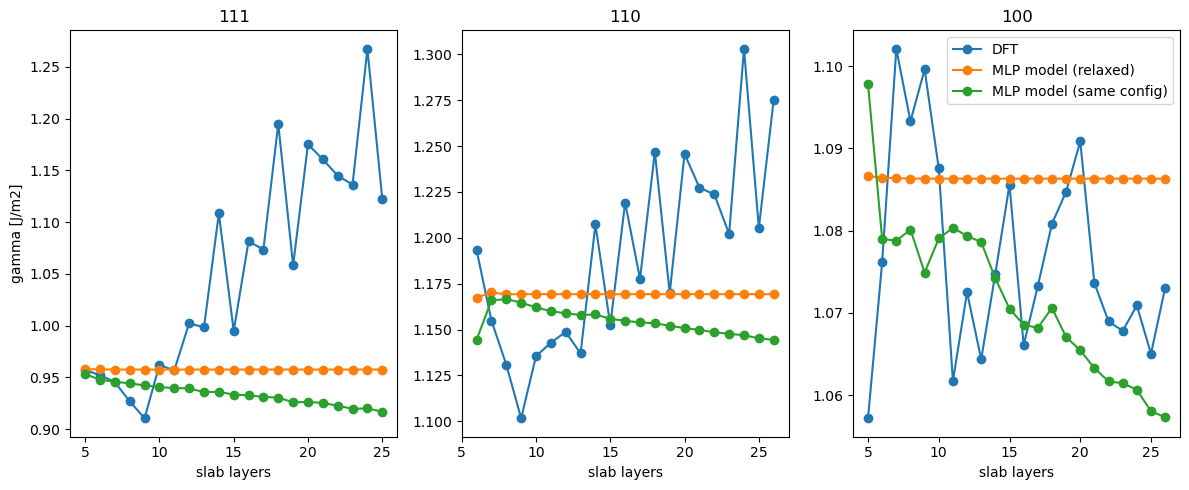

In [21]:
#plot comparison
fig, axs = plt.subplots(1,3, figsize = (12,5))

for miller, ax in zip(millers, axs):
    ax.plot(data[miller]['layers'], data[miller]['ref_gamma'], label='DFT', marker='o')
    ax.plot(data[miller]['layers'], data[miller]['model_relaxed_gamma'], label='MLP model (relaxed)', marker='o')
    ax.plot(data[miller]['layers'], data[miller]['model_gamma'], label='MLP model (same config)', marker='o')

    ax.set_xlabel('slab layers')
    ax.set_title(miller)

axs[0].set_ylabel('gamma [J/m2]')
axs[-1].legend()
plt.tight_layout()

apparently (part of) the problem is in the fixed drift! And probably mace does not get such an error because the slabs are thinner than it enormous cutoff.

Some simulations are currently running on leonardo for unrelaxed surfaces. this way maybe we can get a better understanding?

In the meanwhile: direct comparison of the (total) slab energies.

NameError: name 'reference' is not defined

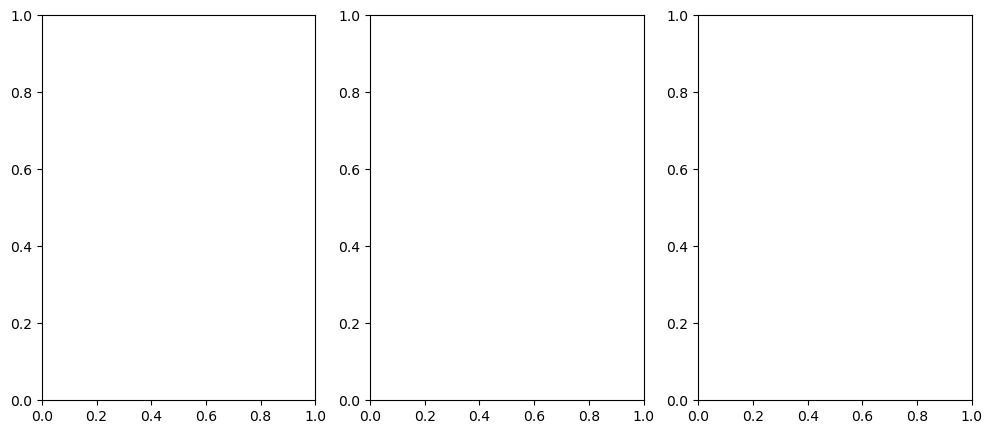

In [20]:
#plot comparison
fig, axs = plt.subplots(1,3, figsize = (12,5))

for miller, ax in zip(millers, axs):
    #ids = np.argsort(reference[miller]['layers'])
    
    ax.plot(reference[miller]['layers'], reference[miller]['energy']/reference[miller]['nat'], label='DFT', marker='o')
    ax.plot(model_data[miller]['layers'], model_data[miller]['energy']/model_data[miller]['nat'], label='MLP model', marker='o')
    #ax.plot(model_data[miller]['layers'], model_data[miller]['energy'] - reference[miller]['energy'][ids])
    ax.set_xlabel('slab layers')
    ax.set_title(miller)

axs[0].set_ylabel('energy [eV]')
axs[-1].legend()
plt.tight_layout()

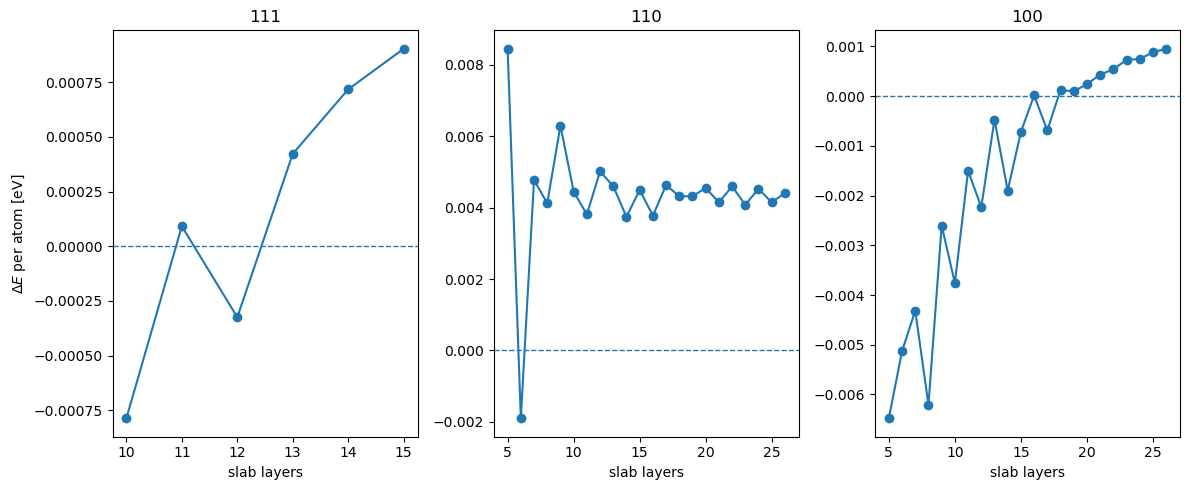

In [ ]:
# plot comparison - per-atom error - OLD
fig, axs = plt.subplots(1, 3, figsize=(12,5))

for miller, ax in zip(millers, axs):

    # --- reference data ---
    ref_layers = np.array(reference[miller]['layers'])
    ref_energy = np.array(reference[miller]['energy'])
    ref_nat = np.array(reference[miller]['nat'])

    ref_ids = np.argsort(ref_layers)

    ref_layers = ref_layers[ref_ids]
    ref_e_per_atom = ref_energy[ref_ids] / ref_nat[ref_ids]

    # --- model data ---
    mdl_layers = np.array(model_same_config[miller]['layers'])
    mdl_energy = np.array(model_same_config[miller]['energy'])
    mdl_nat = np.array(model_same_config[miller]['nat'])

    mdl_ids = np.argsort(mdl_layers)

    mdl_layers = mdl_layers[mdl_ids]
    mdl_e_per_atom = mdl_energy[mdl_ids] / mdl_nat[mdl_ids]

    # --- compute difference ---
    # assumes same layer values exist in both datasets
    common_layers = np.intersect1d(ref_layers, mdl_layers)

    ref_vals = np.array([
        ref_e_per_atom[ref_layers == l][0]
        for l in common_layers
    ])

    mdl_vals = np.array([
        mdl_e_per_atom[mdl_layers == l][0]
        for l in common_layers
    ])

    diff = mdl_vals - ref_vals

    # --- plot difference ---
    ax.plot(common_layers, diff, marker='o')

    ax.axhline(0, linestyle='--', linewidth=1)

    ax.set_xlabel('slab layers')
    ax.set_title(miller)

axs[0].set_ylabel(r'$\Delta E$ per atom [eV]')
plt.tight_layout()

Some drift here as well. This might be due to the different local minima in the configs (each slab is relaxed according to either the potential or the DFT minimum). Let's see if this holds in prediction of fixed positions slabs. Or, due to the fact that by fitting you get different 'cohesive energies' for the different surfaces... while the potential only uses one

Let's check the long-range stability of the surface energy of slabs with the potential and my method.

In [ ]:
from tqdm import tqdm

range_layers = np.arange(2, 50, 2)

n_range = len(range_layers.shape)

g111, g110, g100 = [],  [], []

for layers in tqdm(range_layers):
    results = bm.low_index_surfen(symbol, 
                                  calc, 
                                  alat, 
                                  None, 
                                  size=(1,1,layers), 
                                  relax=True, 
                                  relax_layers=10,
                                  fmax=force_tolerance)
    
    g111.append(results['fcc111']['gamma'])
    g110.append(results['fcc110']['gamma'])
    g100.append(results['fcc100']['gamma'])

g111 = np.asarray(g111)
g110 = np.asarray(g110)
g100 = np.asarray(g100)


100%|██████████| 24/24 [00:16<00:00,  1.42it/s]


Text(0, 0.5, 'gamma J/m2')

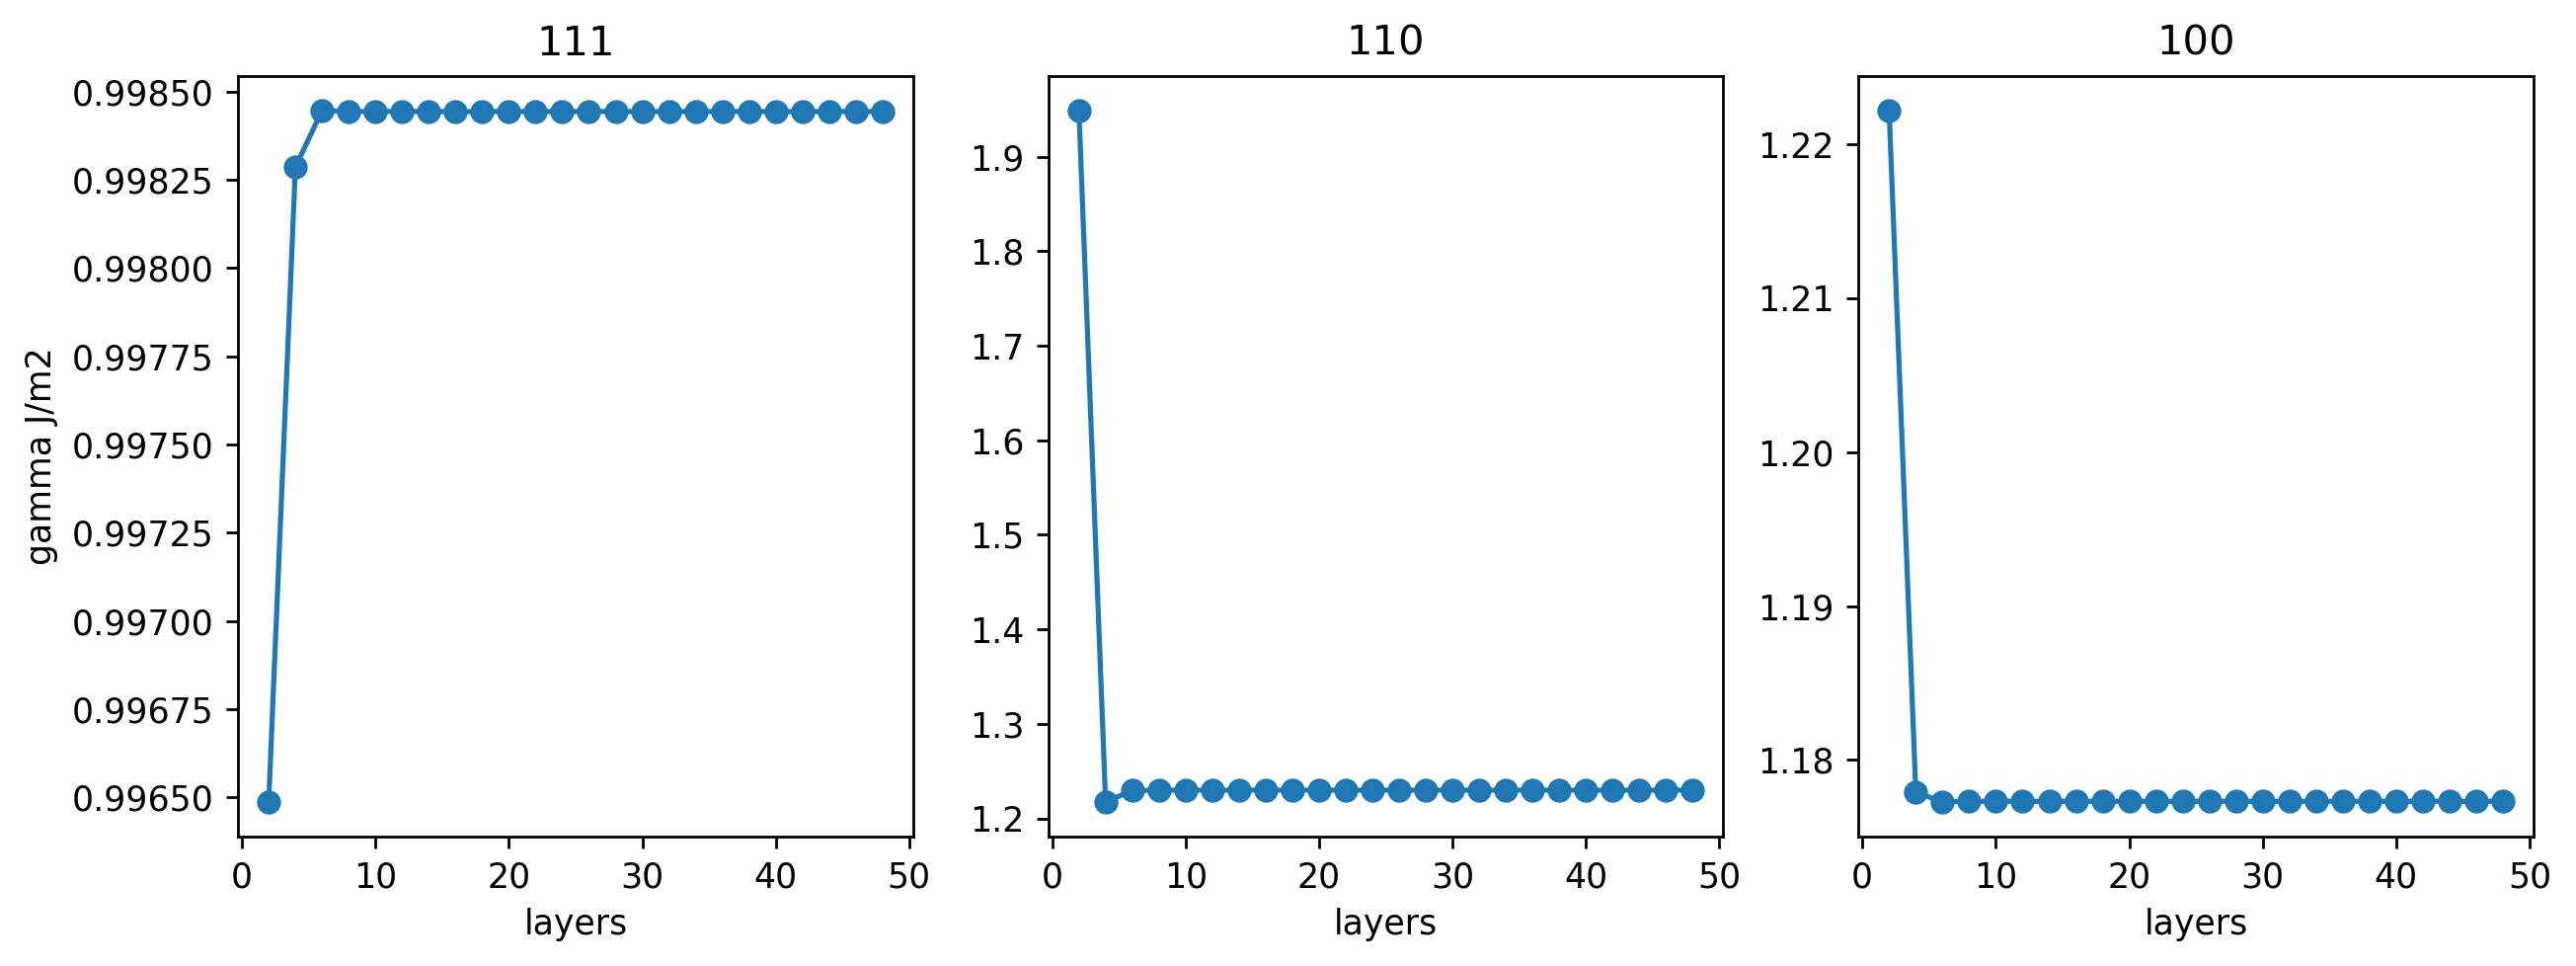

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12,4), dpi=250)

for ax, g, m in zip(axs, [g111, g110, g100], millers):
    ax.plot(range_layers, g, marker='o')
    ax.set_xlabel('layers')
    ax.set_title(m)

axs[0].set_ylabel('gamma J/m2')



If you fix a number of layers to relax on each side, the surface energy is stable on the long run (nice). If you don't, you still have instabilities even when computing on the fly the relaxed bulk energy. 

The surface energy can also be computed from fitting this equation:
$$
E(N) = N\epsilon + 2\gamma A
$$
This way we should reduce the problem of a fixed and possibly faulty cohesive energy?

111 : fitted cohesive energy (DFT) [eV]: -3.794, fitted surface energy (DFT) [J/m2]: 0.832
err. %: 15.082
110 : fitted cohesive energy (DFT) [eV]: -3.797, fitted surface energy (DFT) [J/m2]: 1.081
err. %: 8.224
100 : fitted cohesive energy (DFT) [eV]: -3.807, fitted surface energy (DFT) [J/m2]: 1.085
err. %: 0.142


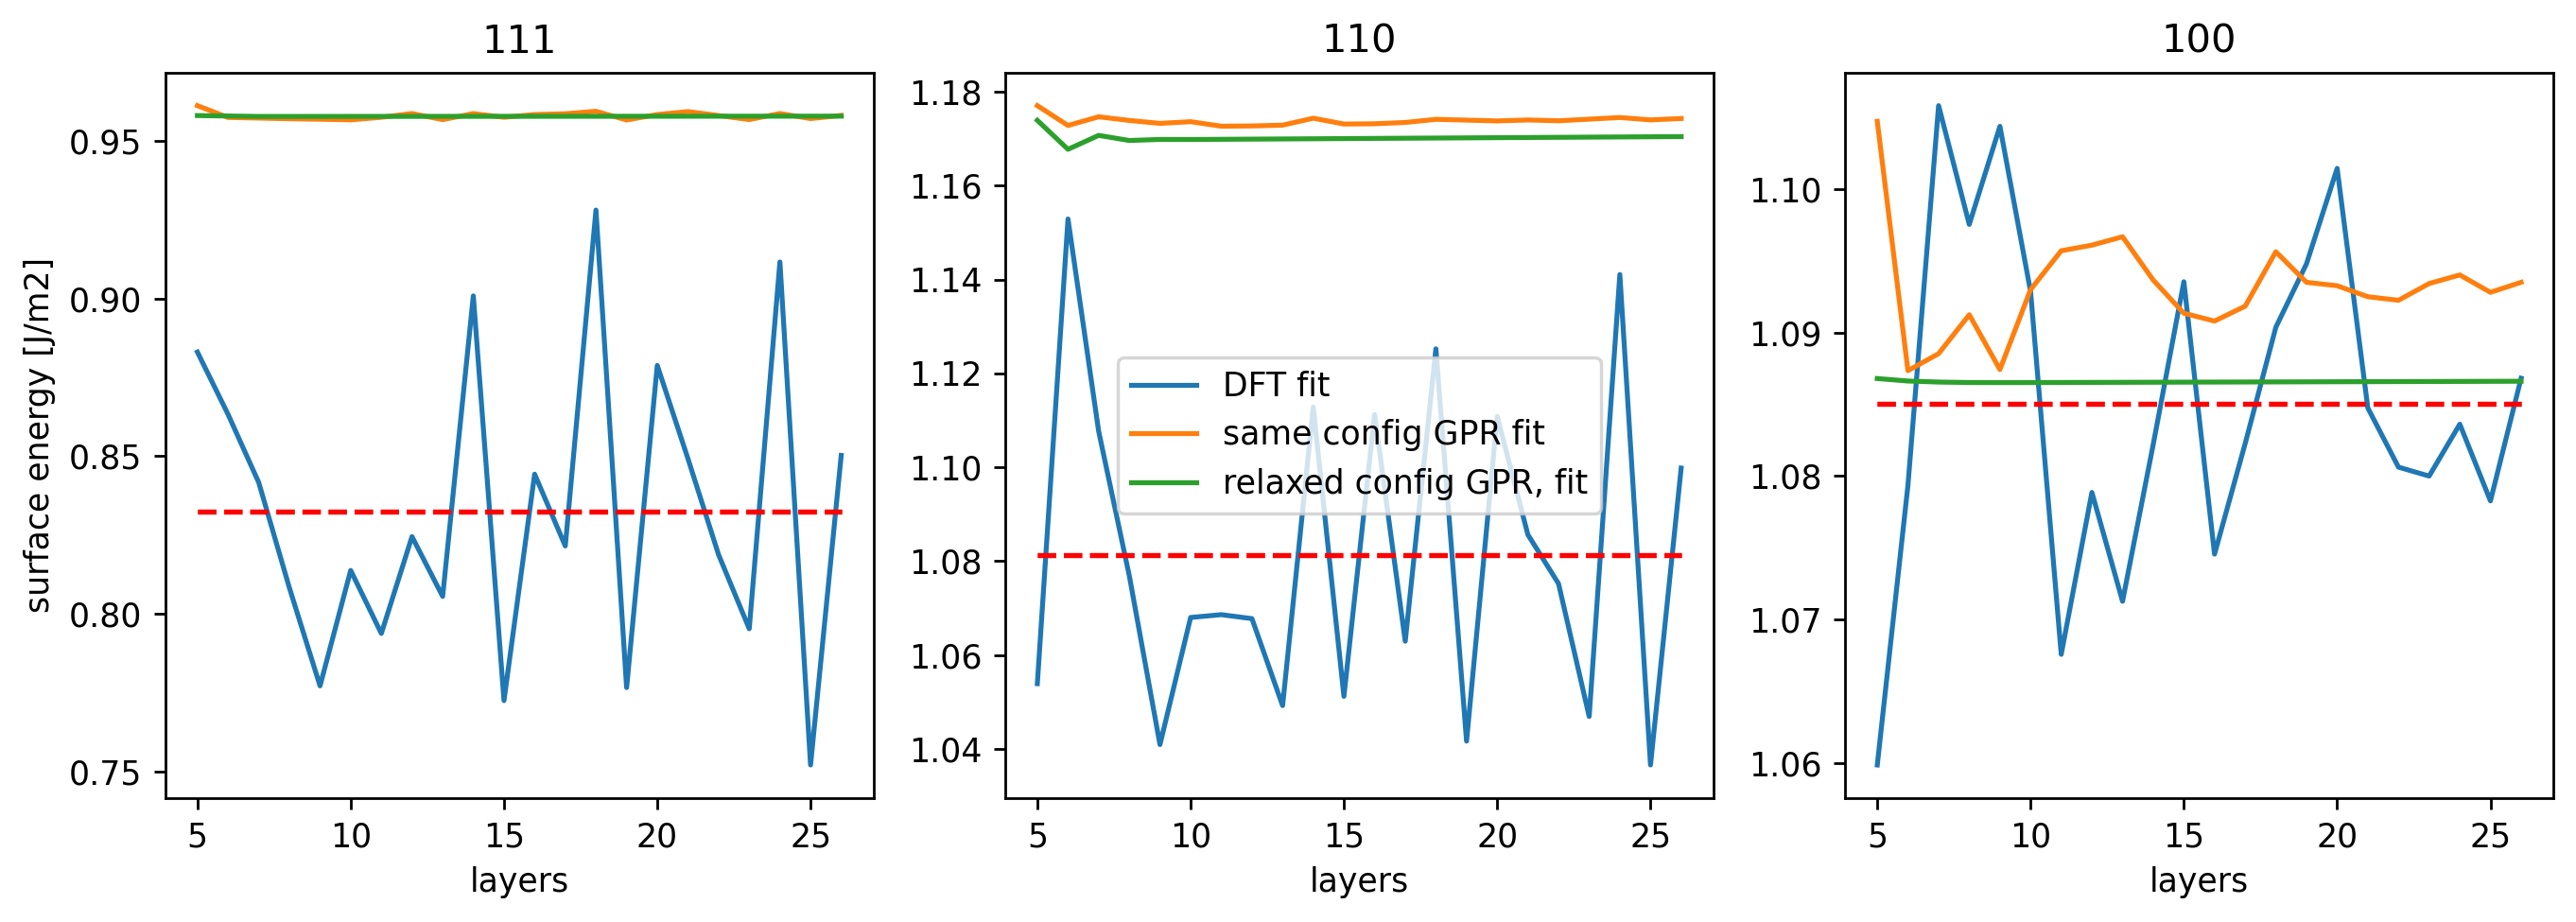

In [ ]:
#use cells above to extract data
#here we use the fitting method to compute surface energies
fig, axs = plt.subplots(1, 3, figsize=(11,4), dpi=250, sharey=False)
for miller, ax in zip(millers, axs):

    d = data[miller]

    A = d['surface']

    p_ref = np.polyfit(d['layers'], d['ref_energy'], deg=1)
    gamma_ref = p_ref[1]/2./A*16.0218
    print(miller,f': fitted cohesive energy (DFT) [eV]: {p_ref[0]:.3f}, fitted surface energy (DFT) [J/m2]: {gamma_ref:.3f}')

    #1 - fit to calculations of the same structure
    p_model_same = np.polyfit(d['layers'], d['model_energy'], deg=1)
    gamma_model_same = p_model_same[1]/2./A*16.0218

    #2 - fit to relaxations with the potential
    p_model_relaxed = np.polyfit(d['layers'], d['model_relaxed_energy'], deg=1)
    gamma_model_relaxed = p_model_relaxed[1]/2./A*16.0218

    ax.set_title(miller)

    ax.plot(d['layers'], (d['ref_energy'] - d['layers']*p_ref[0])/2./A*16.0218,           label='DFT fit') #DFT
    ax.plot(d['layers'], (d['model_energy'] - d['layers']*p_model_same[0])/2./A*16.0218,    label='same config GPR fit')
    ax.plot(d['layers'], (d['model_relaxed_energy'] - d['layers']*p_model_relaxed[0])/2./A*16.0218, label='relaxed config GPR, fit')
    #ax.plot(d['layers'], (d['model_energy'] - d['layers']*p_ref[0])/2./A*16.0218,    label='same config GPR fit with DFT ecoh')
    # ax.plot(d['layers'], d['ref_gamma'], label='DFT calc')
    # ax.plot(d['layers'], d['model_gamma'], label='same config GPR calc')
    # ax.plot(d['layers'], d['model_relaxed_gamma'], label='relaxed GPR calc')

    ax.hlines(gamma_ref, d['layers'][0], d['layers'][-1], 'r', '--')
    ax.hlines(gamma_ref, d['layers'][0], d['layers'][-1], 'r', '--')


    ax.set_xlabel('layers')

    print( f'err. %: {(gamma_model_relaxed-gamma_ref)/gamma_ref*100.:.3f}')


axs[0].set_ylabel('surface energy [J/m2]')
axs[1].legend()
plt.tight_layout()

Per-atom energy error of the potential on the reference configurations:

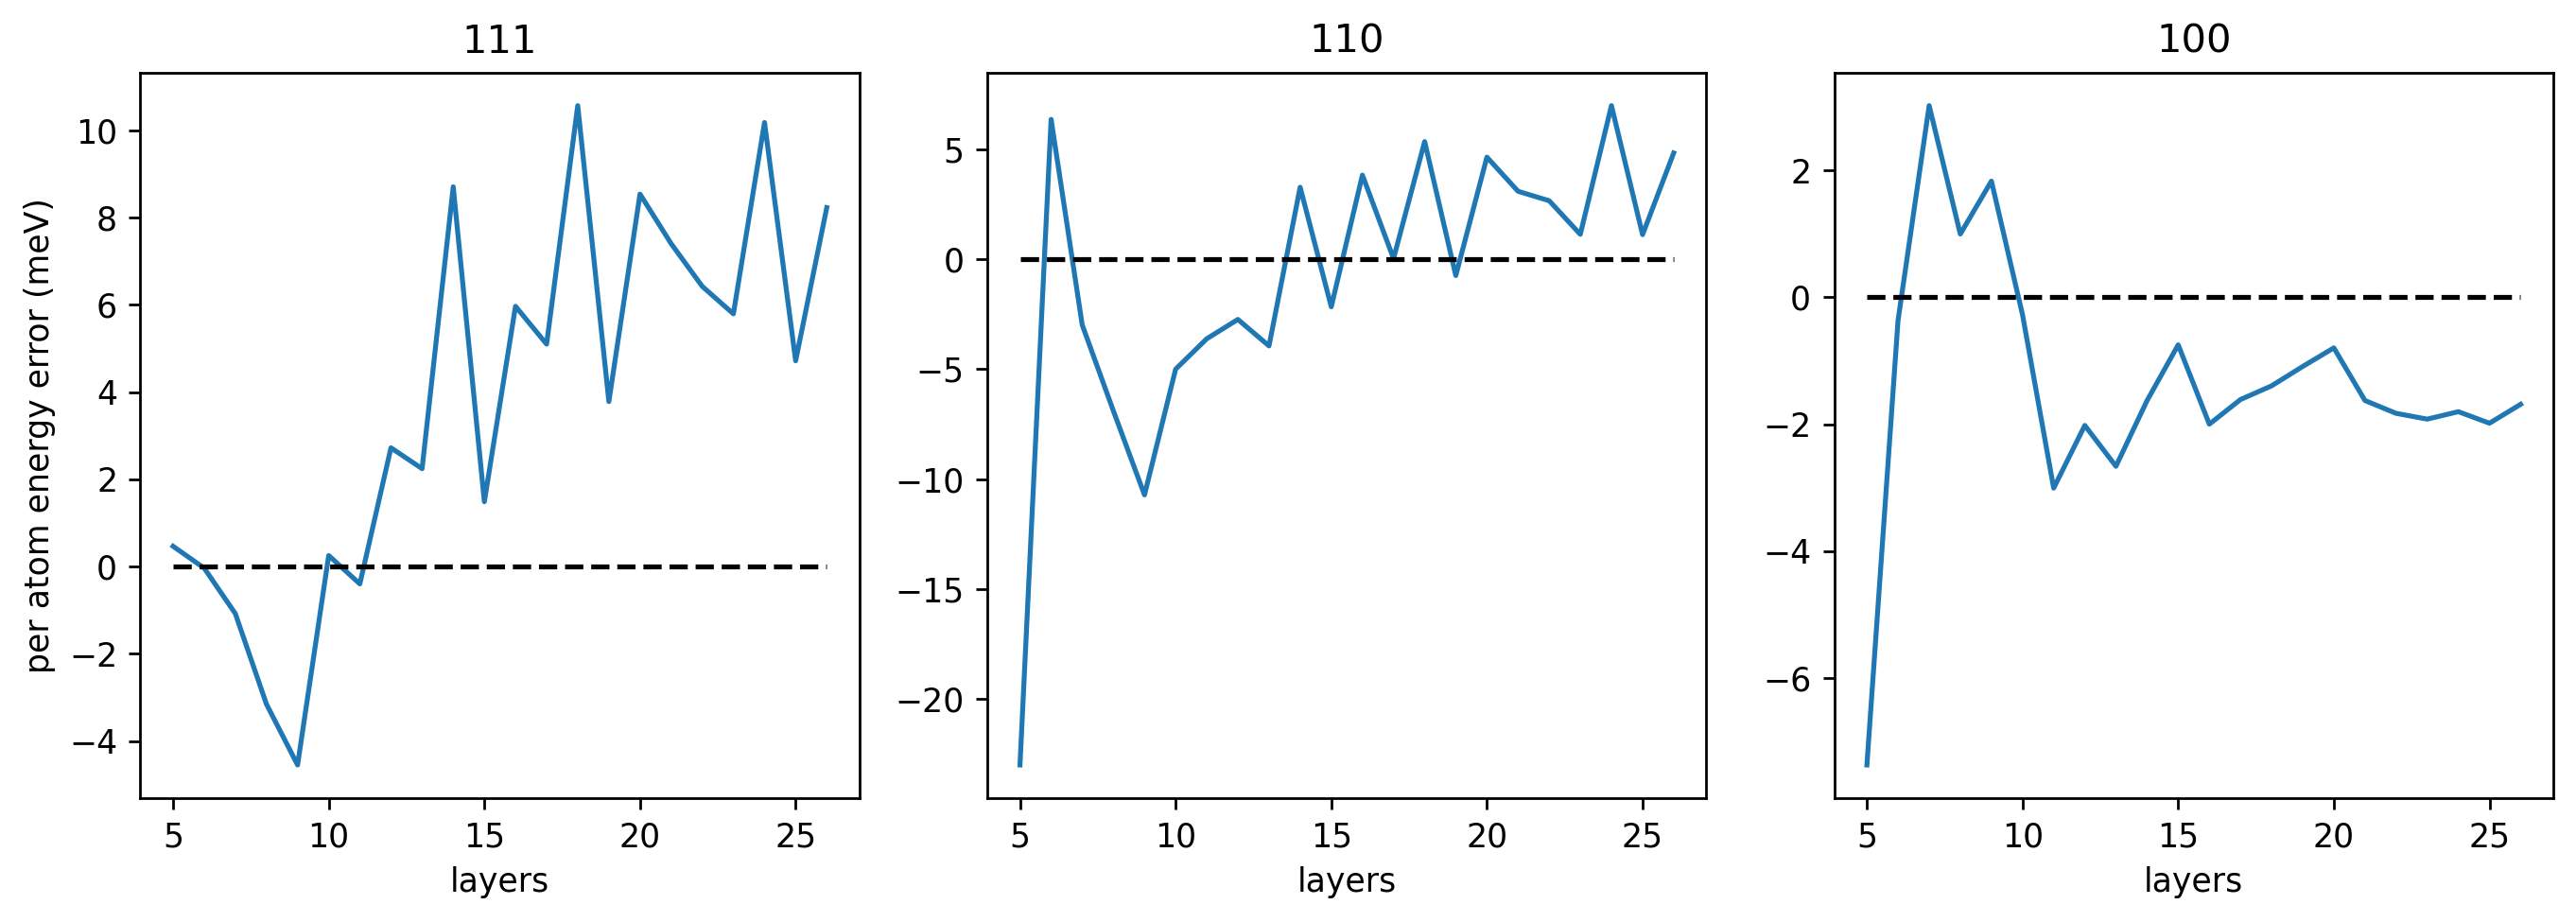

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(11,4), dpi=250)
for miller, ax in zip(millers, axs):
    d = data[miller]
    ax.plot(d['layers'], 1000*(d['ref_energy']-d['model_energy'])/d['layers'])
    ax.hlines(0., d['layers'][0], d['layers'][-1],'k', '--')
    ax.set_xlabel('layers')
    ax.set_title(miller)

axs[0].set_ylabel('per atom energy error (meV)')
plt.tight_layout()
